CAM GENERATION MODULE - Class Activation Maps for CNN Models

ARCHITECTURE:
- BaseCamExtractor: Abstract base class for all CAM extractors
- CamExtractor: Classic CAM using classifier weights × feature maps
- GradCamExtractor: Grad-CAM and Grad-CAM++ using gradients
- CamGenerator: Unified generator with saving and preview

MODEL SUPPORT:
- ResNet: target_layer = model.layer4
- DenseNet: target_layer = model.features.denseblock4
- Others: specify target_layer manually

TYPICAL WORKFLOW:
1. Initialize CamGenerator with model and parameters
2. Call generate_and_save() to generate and save CAMs
3. Use preview_samples() to visualize overlays

OUTPUT FORMATS:
- CAMs: Grayscale uint8 (0-255) saved as JPG
- Preview: RGB overlay with jet colormap
- Dimensions: Configurable via output_size

FILTERING:
- only_class: Save only when prediction == only_class
- Supports binary classification (0/1) for cataracts

DEPENDENCIES:
- pytorch-grad-cam for Grad-CAM/Grad-CAM++
- PIL for image I/O
- matplotlib for visualization
- torch.nn.functional for resizing

In [ ]:
!git clone https://github.com/TheBug95/BIP-Benchmark-2025.git

Cloning into 'BIP-Benchmark-2025'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (360/360), done.
remote: Compressing objects: 100% (319/319), done.
remote: Total 360 (delta 40), reused 360 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (360/360), 8.81 MiB | 14.94 MiB/s, done.
Resolving deltas: 100% (40/40), done.
Updating files: 100% (6657/6657), done.


In [ ]:
import os
import re
import cv2
import random
from typing import Tuple, Optional
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.cm as cm
###from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
#from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm.auto import tqdm
import torch.nn as nn



In [ ]:
class BaseCamExtractor:
    """
    Base class for all CAM extractors.
    Subclasses must implement generate_cam().
    """
    def __init__(self, model):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = model.to(self.device).eval()

    def generate_cam(self, img_tensor) :
        raise NotImplementedError

In [ ]:
class CamExtractor(BaseCamExtractor):
    """CAM using classifier weights × feature maps."""
    def __init__(self, model, target_layer):
        super().__init__(model)
        self._fmap = None
        target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        """
        Hook function to capture feature maps.
        """
        self._fmap = out.detach()

    def _classifier_weights(self, class_id) -> torch.Tensor:
        """Return classifier weights for the predicted class."""
        if hasattr(self.model, "fc") and hasattr(self.model.fc, "weight"):
            return self.model.fc.weight[class_id]          # resnet
        if hasattr(self.model, "classifier") and hasattr(self.model.classifier, "weight"):
            return self.model.classifier.weight[class_id]  # densenet
        raise ValueError("Classifier weights not found")

    def generate_cam(self, img_tensor) :
        self._fmap = None

        with torch.no_grad():
            logits = self.model(img_tensor.to(self.device))
            class_id = int(logits.argmax(1))

        if self._fmap is None:
            raise RuntimeError("Feature map not captured. Check target_layer.")

        fmap = self._fmap.squeeze(0)  # C x H x W
        weights = self._classifier_weights(class_id).to(fmap.device)  # C
        cam = (weights.view(-1, 1, 1) * fmap).sum(0)                  # H x W
        cam_norm = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize to [0, 1]

        return cam_norm.detach().cpu().numpy(), class_id

In [ ]:
class GradCamExtractor(BaseCamExtractor):
    """
    Unified extractor for Grad-CAM e Grad-CAM++.
    Con versioni vecchie di pytorch-grad-cam i flag aug_smooth/eigen_smooth
    vanno passati alla chiamata e NON al costruttore.
    """
    def __init__(self,
                 model,
                 target_layer,
                 cam_type = "gradcam",
                 aug_smooth = False,
                 eigen_smooth = False):
        super().__init__(model)

        cam_type = cam_type.lower()
        if cam_type == "gradcam":
            cam_class = GradCAM
        elif cam_type in ("gradcam++"):
            cam_class = GradCAMPlusPlus
        else:
            raise ValueError("cam_type must be 'gradcam' or 'gradcam++'.")

        # salva i flag per usarli dopo nella call
        self.aug_smooth = aug_smooth
        self.eigen_smooth = eigen_smooth

        # costruttore SENZA aug_smooth/eigen_smooth
        self.cam = cam_class(
            model=self.model,
            target_layers=[target_layer],
        )

    def generate_cam(self, img_tensor):
        # class id dalla tua rete (pred più probabile)
        with torch.no_grad():
            logits = self.model(img_tensor.to(self.device))
            class_id = int(logits.argmax(1))

        # qui passiamo i flag
        grayscale_cam = self.cam(
            input_tensor=img_tensor.to(self.device),
            targets=[ClassifierOutputTarget(class_id)],
            aug_smooth=self.aug_smooth,
            eigen_smooth=self.eigen_smooth
        )[0]

        cam_norm = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)
        return cam_norm, class_id


In [ ]:
class CamGenerator:
    """
    Generate/save CAMs and preview overlays with integrated model loading and transforms.
    All-in-one: load model + setup transforms + generate CAMs.
    """
    def __init__(self, model_path, model_name="resnet18", cam_type="gradcam", target_layer=None,
                 only_class=1, num_classes=2, aug_smooth=True, eigen_smooth=True,
                 input_size=(224, 224), normalize=True):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.only_class = only_class
        self.input_size = input_size
        self.cam_type = cam_type
        self.model_name = model_name

        self.model = self._load_model(model_path, model_name, num_classes)
        self.transform = self._setup_transforms(input_size, normalize)

        # target layer
        if target_layer is None:
            target_layer = self._find_target_layer(model_name)

        # extractor
        cam_type_l = cam_type.lower()
        if cam_type_l == "cam":
            self.extractor = CamExtractor(self.model, target_layer)
        elif cam_type_l in ("gradcam", "gradcam++"):
            self.extractor = GradCamExtractor(
                self.model, target_layer,
                cam_type=cam_type_l,
                aug_smooth=aug_smooth,
                eigen_smooth=eigen_smooth
            )
        else:
            raise ValueError("cam_type must be 'cam', 'gradcam', or 'gradcam++'.")

    def _load_model(self, model_path, model_name, num_classes):
        name = model_name.lower()
        if name == "resnet18":
            model = models.resnet18(pretrained=False)
            model.fc = nn.Linear(model.fc.in_features, num_classes)

        elif name == "densenet121":
            model = models.densenet121(pretrained=False)
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)

        elif name == "convnext_tiny":
            try:
                model = models.convnext_tiny(weights=None)   # torchvision recenti
            except TypeError:
                model = models.convnext_tiny(pretrained=False)  # compat vecchie
            in_feats = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_feats, num_classes)

        else:
            raise ValueError(f"Model {model_name} not supported.")

        state = torch.load(model_path, map_location=self.device)
        model.load_state_dict(state)
        model = model.to(self.device).eval()
        print(f"✅ Model {model_name} loaded from {model_path}")
        return model

    def _setup_transforms(self, input_size, normalize):
        t = [transforms.Resize(input_size), transforms.ToTensor()]
        if normalize:
            t.append(transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                          std=[0.229, 0.224, 0.225]))
        return transforms.Compose(t)

    def _find_target_layer(self, model_name):
        name = model_name.lower()
        if name.startswith("resnet"):
            # preferisci l'ultimo bottleneck se disponibile
            try:
                return self.model.layer4[-1]
            except Exception:
                return self.model.layer4
        if name.startswith("densenet"):
            return self.model.features.denseblock4
        # --- NEW: ConvNeXt Tiny
        if name.startswith("convnext"):
            # target “naturale” per Grad-CAM: depthwise conv dell’ultimo blocco
            try:
                return self.model.features[-1][-1].dwconv
            except Exception:
                # fallback robusto: ultimo stage delle features
                return self.model.features[-1]
        raise ValueError(f"Cannot find target layer for '{model_name}'. Pass it explicitly.")

    @staticmethod
    def _resize_cam(cam, size, device):
        t = torch.from_numpy(cam).float().to(device)
        up = F.interpolate(t.unsqueeze(0).unsqueeze(0), size=size,
                           mode="bilinear", align_corners=False)
        return up.squeeze().detach().cpu().numpy()

    @staticmethod
    def _overlay(img_u8, cam01, alpha=0.4, colormap="jet"):
        """
        img_u8: immagine RGB uint8 [H, W, 3]
        cam01: heatmap [H, W] (qualunque scala) -> normalizzata qui a [0,1]
        """
        alpha = float(np.clip(alpha, 0.0, 1.0))

        # normalizzazione robusta (gestisce costanti/NaN)
        cam = np.nan_to_num(cam01.astype(np.float32))
        cam -= cam.min()
        denom = cam.max() - cam.min()
        cam = cam / (denom + 1e-8)

        # colormap → uint8 [0,255]
        cmap = cm.get_cmap(colormap)
        heat = (cmap(cam)[..., :3] * 255).astype(np.uint8)

        # blending in float32 per evitare troncamenti
        img_f = img_u8.astype(np.float32)
        heat_f = heat.astype(np.float32)

        # cv2.addWeighted non richiede BGR per una semplice somma pesata
        overlay = cv2.addWeighted(img_f, 1.0 - alpha, heat_f, alpha, 0.0)
        return overlay.astype(np.uint8)


    def generate_and_save(self,
                      img_dir,
                      save_dir=None,              # (compat) se lo passi, uso questo
                      save_root=None,             # se save_dir è None → costruisco path auto
                      split_idx=1,
                      output_size=(224, 224),
                      show_example=False,
                      overlay_alpha=0.4):
      if save_dir is None:
          if save_root is None:
              raise ValueError("Specifica save_dir oppure save_root.")
          cam_subdir = self.cam_type.lower()  # "cam" oppure "gradcam" (niente gradcam++)
          save_dir = os.path.join(
              save_root,
              cam_subdir,
              self.model_name.lower(),
              f"split_{split_idx}"
          )

      os.makedirs(save_dir, exist_ok=True)

      # --- raccolta immagini ---
      img_names = sorted([
          n for n in os.listdir(img_dir)
          if n.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
      ])

      saved, shown = 0, False
      for img_name in tqdm(img_names, desc=f"Generating CAMs in {os.path.basename(img_dir)}"):
          img_path = os.path.join(img_dir, img_name)
          img = Image.open(img_path).convert("RGB")
          x = self.transform(img).unsqueeze(0).to(self.device)

          # genera CAM e predizione
          cam01, class_id = self.extractor.generate_cam(x)

          # salva solo se only_class è specificato e la predizione corrisponde
          if self.only_class is not None and int(class_id) != int(self.only_class):
              continue

          # upsample CAM e salva come uint8
          cam_up = self._resize_cam(cam01, output_size, self.device)
          cam_u8 = (np.clip(cam_up, 0, 1) * 255).astype(np.uint8)

          base, _ = os.path.splitext(img_name)
          out_path = os.path.join(save_dir, f"{base}_cam.jpg")
          Image.fromarray(cam_u8).save(out_path)
          saved += 1

          # overlay di esempio (una sola volta, se richiesto)
          if show_example and not shown:
              overlay = self._overlay(np.array(img.resize(output_size)), cam_up, alpha=overlay_alpha)
              plt.figure(figsize=(4, 4)); plt.imshow(overlay); plt.axis("off")
              plt.title(f"{img_name} (pred={class_id})"); plt.show()
              shown = True

      if show_example and not shown:
          print("Nessuna immagine con predizione == only_class → nessuna overlay mostrata.")

      return saved, shown

    def preview_samples(self, img_dir, k=4, output_size=(224, 224), alpha=0.4):
        img_names = [n for n in os.listdir(img_dir)
                     if n.lower().endswith((".jpg", ".jpeg", ".png"))]
        if not img_names:
            print("No images found.")
            return

        sample = random.sample(img_names, k=min(k, len(img_names)))
        plt.figure(figsize=(4 * len(sample), 4))

        for i, name in enumerate(sample, 1):
            path = os.path.join(img_dir, name)
            img = Image.open(path).convert("RGB").resize(output_size)
            x = self.transform(img).unsqueeze(0).to(self.device)

            cam01, class_id = self.extractor.generate_cam(x)
            cam_up = self._resize_cam(cam01, output_size, self.device)
            overlay = self._overlay(np.array(img), cam_up, alpha=alpha)

            plt.subplot(1, len(sample), i)
            plt.imshow(overlay)
            plt.title(f"{name}\npred: {class_id}")
            plt.axis("off")

        plt.tight_layout(); plt.show()

In [ ]:
!unzip /content/trained_models.zip -d /content/

In [ ]:
!unzip /content/valid.zip -d /content/

In [ ]:
#config
models_dir = '/content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv'
validation_img_dir = '/content/valid'
cam_output = '/content/cam'

print("🔧 Configuración actualizada:")
print(f"📁 Modelos: {models_dir}")
print(f"🖼️  Imágenes de validación: {validation_imgs}")
print(f"💾 Salida CAMs: {cam_output}")

🔧 Configuración actualizada:
📁 Modelos: /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv
🖼️  Imágenes de validación: /content/valid
💾 Salida CAMs: /content/cam


📁 Encontrados 50 modelos ResNet18 entrenados

🔄 Procesando modelo: 126_images_split_1.pth
📊 Identificador del modelo: 126images_split1


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/126_images_split_1.pth
✅ Modelo cargado exitosamente


Generating CAMs in valid:   0%|          | 0/59 [00:00<?, ?it/s]

/tmp/ipython-input-3107304161.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


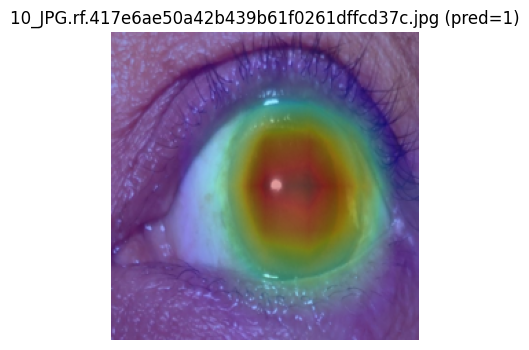

✅ Generadas 59 CAMs para 126images_split1
📁 Guardadas en: /content/cam/resnet18_126images_split1

🔄 Procesando modelo: 126_images_split_10.pth
📊 Identificador del modelo: 126images_split10
✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/126_images_split_10.pth
✅ Modelo cargado exitosamente


Generating CAMs in valid:   0%|          | 0/59 [00:00<?, ?it/s]

✅ Generadas 59 CAMs para 126images_split10
📁 Guardadas en: /content/cam/resnet18_126images_split10

🔄 Procesando modelo: 126_images_split_2.pth
📊 Identificador del modelo: 126images_split2
✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/126_images_split_2.pth
✅ Modelo cargado exitosamente


Generating CAMs in valid:   0%|          | 0/59 [00:00<?, ?it/s]

✅ Generadas 59 CAMs para 126images_split2
📁 Guardadas en: /content/cam/resnet18_126images_split2

🔄 Procesando modelo: 126_images_split_3.pth
📊 Identificador del modelo: 126images_split3
✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/126_images_split_3.pth
✅ Modelo cargado exitosamente


...

✅ Generadas 59 CAMs para 84images_split7
📁 Guardadas en: /content/cam/resnet18_84images_split7

🔄 Procesando modelo: 84_images_split_8.pth
📊 Identificador del modelo: 84images_split8
✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/84_images_split_8.pth
✅ Modelo cargado exitosamente


Generating CAMs in valid:   0%|          | 0/59 [00:00<?, ?it/s]

✅ Generadas 59 CAMs para 84images_split8
📁 Guardadas en: /content/cam/resnet18_84images_split8

🔄 Procesando modelo: 84_images_split_9.pth
📊 Identificador del modelo: 84images_split9
✅ Model resnet18 loaded from /content/content/BIP-Benchmark-2025/dataset/trained_models/resnet18_last_conv/84_images_split_9.pth
✅ Modelo cargado exitosamente


Generating CAMs in valid:   0%|          | 0/59 [00:00<?, ?it/s]

✅ Generadas 59 CAMs para 84images_split9
📁 Guardadas en: /content/cam/resnet18_84images_split9

📊 RESUMEN FINAL:
✅ Modelos procesados: 50/50
🖼️  Total CAMs generadas: 2950
📁 Directorio de salida: /content/cam


In [ ]:
model_name = 'resnet18'
cam_type = 'cam'

# Crear directorio de salida
os.makedirs(cam_dir, exist_ok=True)

# Obtener lista de modelos ResNet18 entrenados
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pth')]
print(f"📁 Encontrados {len(model_files)} modelos ResNet18 entrenados")

# Procesar cada modelo individualmente
total_models_processed = 0
total_cams_generated = 0

for model_file in sorted(model_files):
    print(f"\n{'='*60}")
    print(f"🔄 Procesando modelo: {model_file}")

    # Extraer información del modelo: "126_images_split_1.pth" -> dataset_size="126", split_num="1"
    try:
        base_name = model_file.replace('.pth', '')
        parts = base_name.split('_')
        dataset_size = parts[0]  # "126", "168", etc.
        split_num = parts[-1]    # "1", "2", etc.

        model_identifier = f"{dataset_size}images_split{split_num}"
        print(f"📊 Identificador del modelo: {model_identifier}")

    except Exception as e:
        print(f"❌ Error analizando nombre del archivo {model_file}: {e}")
        continue

    # Crear directorio específico para este modelo
    current_save_dir = os.path.join(cam_dir, f"resnet18_{dataset_size}images_split{split_num}")
    os.makedirs(current_save_dir, exist_ok=True)

    try:
        model_path = os.path.join(models_dir, model_file)

        generator = CamGenerator(
            model_path=model_path,
            model_name=model_name,
            cam_type=cam_type,
            only_class=None  # Procesar todas las predicciones
        )

        print(f"✅ Modelo cargado exitosamente")

        # Generar CAMs para todas las imágenes de validación
        saved, shown = generator.generate_and_save(
            img_dir=validation_img_dir,
            save_dir=current_save_dir,
            output_size=(224, 224),
            show_example=(total_models_processed == 0)  # Mostrar ejemplo solo para el primer modelo
        )

        total_cams_generated += saved
        total_models_processed += 1

        print(f"✅ Generadas {saved} CAMs para {model_identifier}")
        print(f"📁 Guardadas en: {current_save_dir}")

    except Exception as e:
        print(f"❌ Error procesando modelo {model_file}: {e}")
        continue

print(f"\n{'='*60}")
print(f"📊 RESUMEN FINAL:")
print(f"{'='*60}")
print(f"✅ Modelos procesados: {total_models_processed}/{len(model_files)}")
print(f"🖼️  Total CAMs generadas: {total_cams_generated}")
print(f"📁 Directorio de salida: {cam_dir}")
print(f"{'='*60}")

In [ ]:
!zip -r /content/cam.zip /content/cam
from google.colab import files
files.download('/content/cam.zip')

  adding: content/cam/ (stored 0%)
  adding: content/cam/resnet18_84images_split2/ (stored 0%)
  adding: content/cam/resnet18_84images_split2/12_jpg.rf.718c913bf0e0609c90d569681c70daae_cam.jpg (deflated 9%)
  adding: content/cam/resnet18_84images_split2/5_jpg.rf.89a7df5e05d3b12ee3213814a4d57ef8_cam.jpg (deflated 5%)
  adding: content/cam/resnet18_84images_split2/17_jpg.rf.e9ed9693c949a3a7be921faef3d2772e_cam.jpg (deflated 6%)
  adding: content/cam/resnet18_84images_split2/16_jpg.rf.68d1dbfe2d59e0d740dc1d22b36f4955_cam.jpg (deflated 6%)
  adding: content/cam/resnet18_84images_split2/15_jpg.rf.0efd7ae36e54128ce3b394198b5f88f4_cam.jpg (deflated 4%)
  adding: content/cam/resnet18_84images_split2/25_jpg.rf.5739419f324b59e96bfeb64a0f9d303a_cam.jpg (deflated 7%)
  adding: content/cam/resnet18_84images_split2/23_JPG_jpg.rf.61233790a42c28c4d5872ca3af984219_cam.jpg (deflated 7%)
  adding: content/cam/resnet18_84images_split2/27_jpg.rf.d096f15675ecfd66f1721052d5175a2e_cam.jpg (deflated 5%)
  addi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Configuración para extraer CAMs de imágenes de validación con modelos ResNet18 entrenados
validation_img_dir = r'D:\benchmark-medical-segmentation\Finetuning modelos SAM2, MedSAM2, MobileSAM\Paper BIP 2025\2\final_code\data_partitions\valid'
models_dir = r'D:\benchmark-medical-segmentation\Finetuning modelos SAM2, MedSAM2, MobileSAM\Paper BIP 2025\2\final_code\Resultados Entrenamiento y modelos entrenados\trained_models\content\BIP-Benchmark-2025\dataset\trained_models\resnet18_last_conv'
cam_output_dir = r'D:\benchmark-medical-segmentation\Finetuning modelos SAM2, MedSAM2, MobileSAM\Paper BIP 2025\2\final_code\CAMs_validation'

model_name = 'resnet18'
cam_type = 'gradcam'

# Crear directorio de salida si no existe
os.makedirs(cam_output_dir, exist_ok=True)

# Obtener lista de modelos entrenados
model_files = [f for f in os.listdir(models_dir) if f.endswith('.pth')]
print(f"Found {len(model_files)} trained models:")
for model_file in sorted(model_files):
    print(f"  - {model_file}")

print(f"\nValidation images directory: {validation_img_dir}")
print(f"Output CAMs directory: {cam_output_dir}")

In [ ]:
# Procesar cada modelo entrenado para extraer CAMs de las imágenes de validación
total_models_processed = 0
total_cams_generated = 0

for model_file in sorted(model_files):
    print(f"\n{'='*60}")
    print(f"Processing model: {model_file}")
    print(f"{'='*60}")

    # Extraer información del modelo (dataset_size y split)
    # Formato esperado: "126_images_split_1.pth", "168_images_split_2.pth", etc.
    try:
        base_name = model_file.replace('.pth', '')
        parts = base_name.split('_')
        dataset_size = parts[0]  # "126", "168", etc.
        split_num = parts[-1]    # "1", "2", etc.

        model_identifier = f"{dataset_size}images_split{split_num}"
        print(f"Model identifier: {model_identifier}")

    except Exception as e:
        print(f"Error parsing model filename {model_file}: {e}")
        continue

    # Crear directorio específico para este modelo
    model_output_dir = os.path.join(cam_output_dir, f"resnet18_{dataset_size}images_split{split_num}")
    os.makedirs(model_output_dir, exist_ok=True)

    try:
        # Inicializar el generador CAM para este modelo
        model_path = os.path.join(models_dir, model_file)

        generator = CamGenerator(
            model_path=model_path,
            model_name=model_name,
            cam_type=cam_type,
            only_class=None,  # Procesar todas las predicciones, no filtrar por clase
            num_classes=2
        )

        print(f"✅ Model loaded successfully")
        print(f"Output directory: {model_output_dir}")

        # Generar CAMs para todas las imágenes de validación
        saved_count, shown = generator.generate_and_save(
            img_dir=validation_img_dir,
            save_dir=model_output_dir,
            output_size=(224, 224),
            show_example=(total_models_processed == 0)  # Mostrar ejemplo solo para el primer modelo
        )

        total_cams_generated += saved_count
        total_models_processed += 1

        print(f"✅ Generated {saved_count} CAMs for {model_identifier}")
        print(f"   Saved in: {model_output_dir}")

    except Exception as e:
        print(f"❌ Error processing model {model_file}: {e}")
        continue

print(f"\n{'='*60}")
print(f"RESUMEN FINAL:")
print(f"{'='*60}")
print(f"Modelos procesados: {total_models_processed}/{len(model_files)}")
print(f"Total CAMs generadas: {total_cams_generated}")
print(f"Directorio de salida: {cam_output_dir}")
print(f"{'='*60}")

In [ ]:
# Funciones de utilidad para analizar los resultados
def analyze_cam_results(cam_output_dir):
    """Analiza los resultados de extracción de CAMs"""

    if not os.path.exists(cam_output_dir):
        print(f"❌ El directorio {cam_output_dir} no existe")
        return

    model_dirs = [d for d in os.listdir(cam_output_dir)
                  if os.path.isdir(os.path.join(cam_output_dir, d))]

    print(f"📊 ANÁLISIS DE RESULTADOS CAM")
    print(f"{'='*50}")
    print(f"Directorio base: {cam_output_dir}")
    print(f"Modelos procesados: {len(model_dirs)}")
    print(f"{'='*50}")

    total_cams = 0
    for model_dir in sorted(model_dirs):
        model_path = os.path.join(cam_output_dir, model_dir)
        cam_files = [f for f in os.listdir(model_path) if f.endswith('_cam.jpg')]
        total_cams += len(cam_files)

        print(f"📁 {model_dir}")
        print(f"   CAMs generadas: {len(cam_files)}")

        # Mostrar algunas CAMs de ejemplo
        if len(cam_files) > 0:
            print(f"   Ejemplos: {', '.join(cam_files[:3])}{'...' if len(cam_files) > 3 else ''}")
        print()

    print(f"🎯 TOTAL CAMs generadas: {total_cams}")
    return total_cams

def preview_cam_results(cam_output_dir, model_name=None, num_samples=4):
    """Muestra una vista previa de las CAMs generadas"""

    if not os.path.exists(cam_output_dir):
        print(f"❌ El directorio {cam_output_dir} no existe")
        return

    model_dirs = [d for d in os.listdir(cam_output_dir)
                  if os.path.isdir(os.path.join(cam_output_dir, d))]

    if model_name:
        model_dirs = [d for d in model_dirs if model_name.lower() in d.lower()]

    if not model_dirs:
        print("❌ No se encontraron directorios de modelos")
        return

    # Seleccionar el primer modelo para preview
    selected_model = model_dirs[0]
    model_path = os.path.join(cam_output_dir, selected_model)
    cam_files = [f for f in os.listdir(model_path) if f.endswith('_cam.jpg')]

    if len(cam_files) == 0:
        print(f"❌ No se encontraron CAMs en {selected_model}")
        return

    print(f"🖼️  Vista previa de CAMs del modelo: {selected_model}")

    # Seleccionar muestras aleatorias
    samples = random.sample(cam_files, min(num_samples, len(cam_files)))

    plt.figure(figsize=(4 * len(samples), 8))

    for i, cam_file in enumerate(samples):
        # Cargar CAM
        cam_path = os.path.join(model_path, cam_file)
        cam_img = Image.open(cam_path)

        # Buscar imagen original correspondiente
        orig_name = cam_file.replace('_cam.jpg', '.jpg')
        orig_path = os.path.join(validation_img_dir, orig_name)

        # Mostrar CAM
        plt.subplot(2, len(samples), i + 1)
        plt.imshow(cam_img, cmap='jet')
        plt.title(f"CAM: {cam_file}")
        plt.axis('off')

        # Mostrar imagen original si existe
        if os.path.exists(orig_path):
            plt.subplot(2, len(samples), i + 1 + len(samples))
            orig_img = Image.open(orig_path)
            plt.imshow(orig_img)
            plt.title(f"Original: {orig_name}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar análisis después de la extracción
print("🔍 Analizando resultados...")

In [ ]:
# Ejecutar análisis y vista previa de resultados
try:
    # Analizar resultados
    total_generated = analyze_cam_results(cam_output_dir)

    # Mostrar vista previa si se generaron CAMs
    if total_generated > 0:
        print("\n" + "="*50)
        preview_cam_results(cam_output_dir, num_samples=3)
    else:
        print("❌ No se generaron CAMs para mostrar")

except Exception as e:
    print(f"❌ Error en el análisis: {e}")

print("\n✅ Proceso completado!")